# DATA GENERATION
| Category       | Feature                                     | Description                                                             |
| -------------- | ------------------------------------------- | ----------------------------------------------------------------------- |
| Heart Rate     | `heart_rate`                                | BPM readings, spikes indicate panic                                     |
| Motion         | `accel_x, accel_y, accel_z`                 | 3-axis accelerometer data                                               |
| Derived Motion | `movement_type`                             | walk/run/fall/struggle (based on acceleration pattern)                  |
| Audio          | `sound_db`, `sound_event`                   | decibel level + detected background noise (e.g., shouting, car screech) |
| Location       | `latitude`, `longitude`, `is_isolated_area` | GPS and area safety flag                                                |
| Gesture        | `gesture_sos`                               | binary — 1 if double tap/twist detected                                 |
| Target         | `label`                                     | “Safe” (0) or “Distress” (1)                                            |


✅ Dataset shape: (1500, 12)
   heart_rate   accel_x   accel_y   accel_z movement_type   sound_db  \
0   84.967142  0.333508 -0.472342 -0.087634          walk  38.859186   
1   78.617357 -0.065356 -0.158116 -0.205753          idle  43.690692   
2   86.476885 -0.145460 -0.024082 -0.275077          walk  40.579398   
3   95.230299  0.098988  0.666306  0.323900          walk  44.520042   
4   77.658466  0.048945  0.266966  0.135780          walk  47.858497   

  sound_event   latitude  longitude  is_isolated_area  gesture_sos  label  
0     talking  35.724572  75.458137                 0            0      0  
1     talking  14.227319  84.358463                 1            0      0  
2      normal  22.983264  83.457886                 1            0      0  
3     talking  29.344504  71.999066                 0            0      0  
4      normal  24.148488  85.146044                 0            0      0  


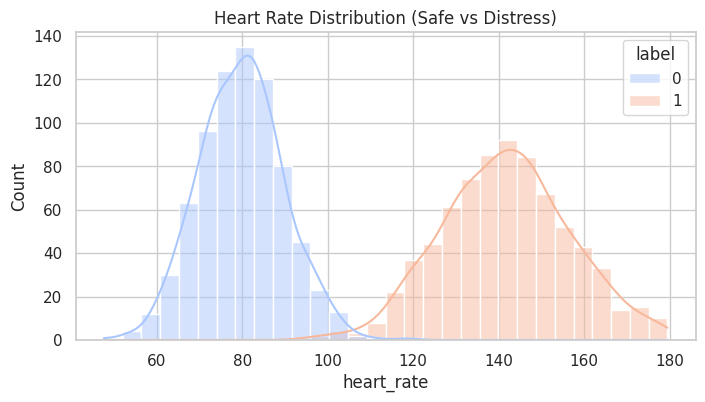

/tmp/ipython-input-1613191898.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="sound_db", data=df, palette="coolwarm")


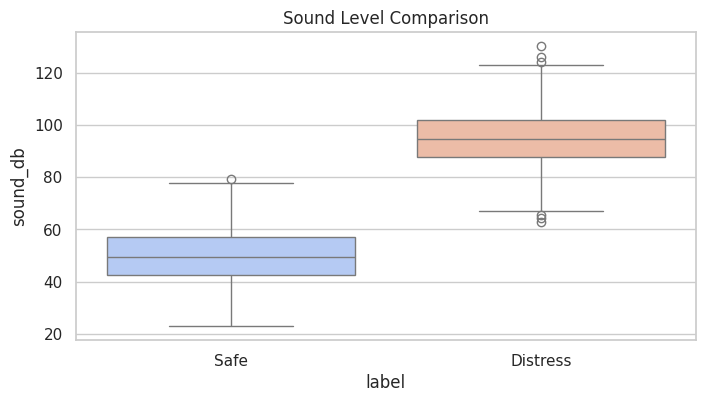

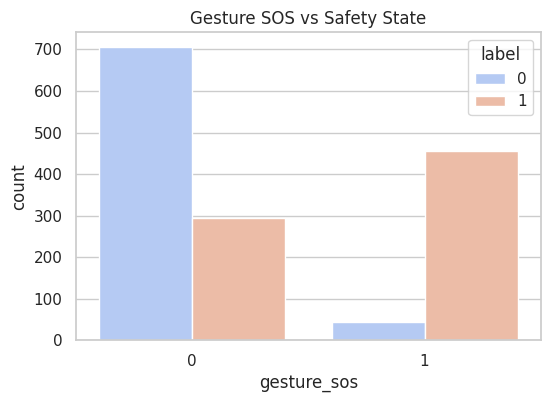

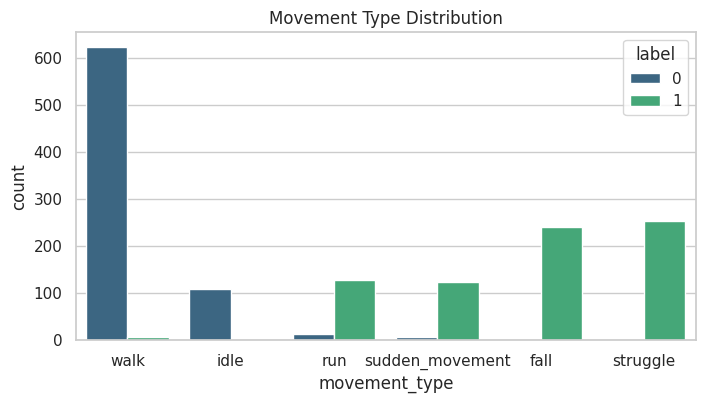

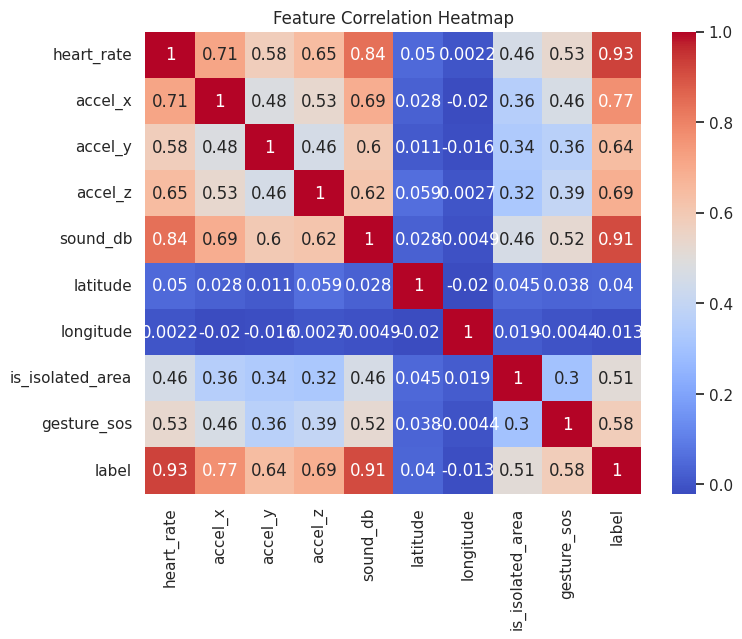

💾 Saved dataset as 'smartwatch_safety_dataset.csv'


In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# CONFIGURATION
# -----------------------------
np.random.seed(42)
num_samples = 1500

# -----------------------------
# 1️⃣ Simulate Features
# -----------------------------

# Heart rate: Normal (60–100), Panic (110–180)
heart_rate = np.concatenate([
    np.random.normal(80, 10, num_samples//2),    # safe
    np.random.normal(140, 15, num_samples//2)    # distress
])

# Accelerometer data
accel_x = np.concatenate([
    np.random.normal(0.1, 0.3, num_samples//2),
    np.random.normal(1.5, 0.8, num_samples//2)
])
accel_y = np.concatenate([
    np.random.normal(0.1, 0.3, num_samples//2),
    np.random.normal(1.3, 0.9, num_samples//2)
])
accel_z = np.concatenate([
    np.random.normal(0.2, 0.3, num_samples//2),
    np.random.normal(1.7, 1.0, num_samples//2)
])

# Sound data: Normal 30–60 dB, Distress 80–120 dB
sound_db = np.concatenate([
    np.random.normal(50, 10, num_samples//2),
    np.random.normal(95, 10, num_samples//2)
])

sound_event = np.array([
    random.choice(["normal", "talking", "birds"]) for _ in range(num_samples//2)
] + [
    random.choice(["shouting", "glass_breaking", "car_screech"]) for _ in range(num_samples//2)
])

# GPS coordinates (random India locations)
latitude = np.random.uniform(8, 37, num_samples)
longitude = np.random.uniform(68, 97, num_samples)

# Isolated area (less populated = higher risk)
is_isolated_area = np.concatenate([
    np.random.binomial(1, 0.2, num_samples//2),
    np.random.binomial(1, 0.7, num_samples//2)
])

# Gesture SOS (double tap, twist)
gesture_sos = np.concatenate([
    np.random.binomial(1, 0.05, num_samples//2),
    np.random.binomial(1, 0.6, num_samples//2)
])

# Movement type classification based on accel variance
def classify_movement(ax, ay, az):
    magnitude = np.sqrt(ax**2 + ay**2 + az**2)
    if magnitude < 0.3:
        return "idle"
    elif magnitude < 1.0:
        return "walk"
    elif magnitude < 2.5:
        return random.choice(["run", "sudden_movement"])
    else:
        return random.choice(["fall", "struggle"])

movement_type = [classify_movement(ax, ay, az) for ax, ay, az in zip(accel_x, accel_y, accel_z)]

# Labels: 0 = safe, 1 = distress
label = np.array([0]*(num_samples//2) + [1]*(num_samples//2))

# -----------------------------
# 2️⃣ Combine into DataFrame
# -----------------------------
df = pd.DataFrame({
    "heart_rate": heart_rate,
    "accel_x": accel_x,
    "accel_y": accel_y,
    "accel_z": accel_z,
    "movement_type": movement_type,
    "sound_db": sound_db,
    "sound_event": sound_event,
    "latitude": latitude,
    "longitude": longitude,
    "is_isolated_area": is_isolated_area,
    "gesture_sos": gesture_sos,
    "label": label
})

print("✅ Dataset shape:", df.shape)
print(df.head())

# -----------------------------
# 3️⃣ Visualizations
# -----------------------------
sns.set(style="whitegrid")

# 1. Heart Rate Distribution
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="heart_rate", hue="label", kde=True, bins=30, palette="coolwarm")
plt.title("Heart Rate Distribution (Safe vs Distress)")
plt.show()

# 2. Sound Intensity Comparison
plt.figure(figsize=(8,4))
sns.boxplot(x="label", y="sound_db", data=df, palette="coolwarm")
plt.title("Sound Level Comparison")
plt.xticks([0,1], ["Safe", "Distress"])
plt.show()

# 3. Gesture SOS Count
plt.figure(figsize=(6,4))
sns.countplot(x="gesture_sos", hue="label", data=df, palette="coolwarm")
plt.title("Gesture SOS vs Safety State")
plt.show()

# 4. Movement Type Frequency
plt.figure(figsize=(8,4))
sns.countplot(x="movement_type", hue="label", data=df, palette="viridis")
plt.title("Movement Type Distribution")
plt.show()

# 5. Correlation Heatmap (numerical features)
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Save dataset
df.to_csv("smartwatch_safety_dataset.csv", index=False)
print("💾 Saved dataset as 'smartwatch_safety_dataset.csv'")


# Preprocessing + Feature Engineering

Preprocessing

| Step    | Operation                  | Description                                                      | Why It’s Needed                                    |
| ------- | -------------------------- | ---------------------------------------------------------------- | -------------------------------------------------- |
| **2.1** | Handle Missing Data        | Replace nulls, sensor dropouts                                   | Real devices may skip readings                     |
| **2.2** | Remove Outliers            | Clip unrealistic heart rates (>200 bpm) or sound (>120 dB)       | Prevents noise from dominating                     |
| **2.3** | Normalize Features         | Scale between 0–1 or z-score                                     | Ensures all sensors contribute equally             |
| **2.4** | Compute Rolling Statistics | e.g., 5s average heart rate, sound                               | Captures trends, not single spikes                 |
| **2.5** | Compute Rate of Change     | Δheart_rate / Δtime, Δacceleration                               | Helps detect sudden panic or movement              |
| **2.6** | Aggregate by Event         | Take mean, max, variance, range for each event window            | Reduces continuous data into usable feature vector |
| **2.7** | Encode Categories          | Convert movement types into numeric form                         | For ML model compatibility                         |
| **2.8** | Feature Synthesis          | Derive secondary features like “HR spike rate × sound intensity” | Increases signal richness                          |


Feature engineering


| Feature Name                            | Derived From                              | Meaning                 |
| --------------------------------------- | ----------------------------------------- | ----------------------- |
| `hr_mean`, `hr_max`, `hr_std`           | Heart rate                                | Stress indicator        |
| `hr_spike_rate`                         | HR slope over time                        | Panic intensity         |
| `motion_variance`                       | Accelerometer                             | Struggle/fall detection |
| `sound_mean`, `sound_peak`, `sound_var` | Microphone decibels                       | Environment threat      |
| `gesture_freq`                          | Gesture data                              | Manual SOS attempts     |
| `gps_isolation`                         | GPS density or distance from city area    | Location danger         |
| `combined_stress_score`                 | Weighted sum of HR + sound + accel spikes | Single scalar for AI    |
| `label`                                 | Safe or Distress                          | Ground truth            |




/tmp/ipython-input-680931389.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-680931389.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='stress_score', data=df, palette='coolwarm')


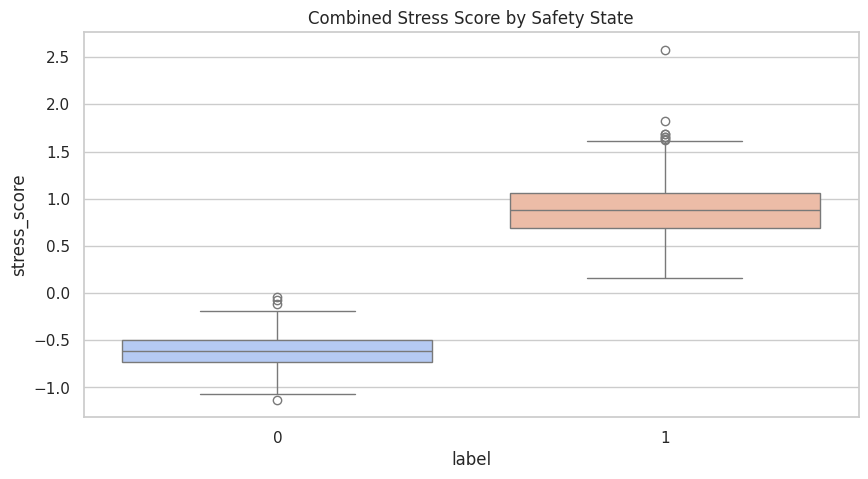

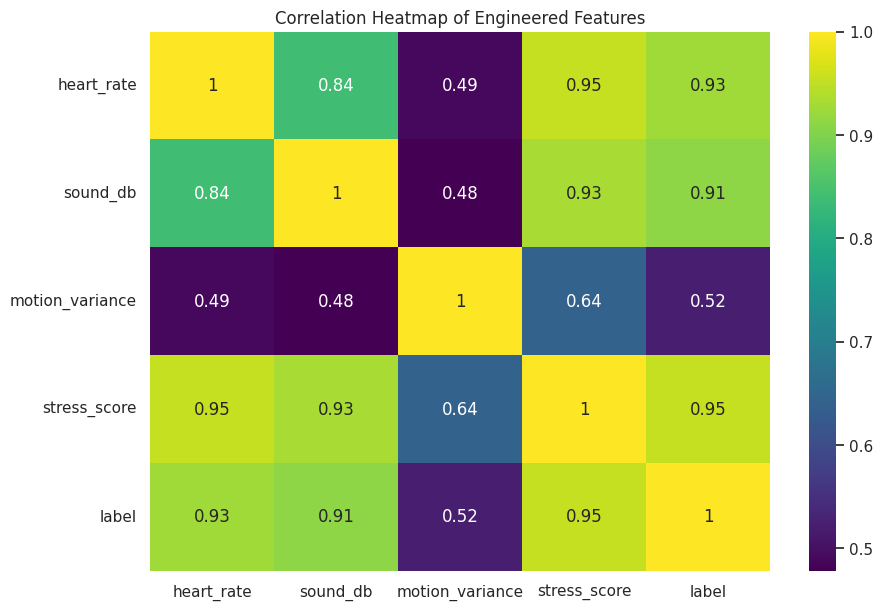

✅ Preprocessing complete. Data saved as processed_safety_data.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df is your synthetic dataset from the previous step

# 1. Handle missing data (if any)
df = df.fillna(method='ffill').fillna(method='bfill')

# 2. Remove extreme outliers
df = df[(df['heart_rate'] < 200) & (df['sound_db'] < 120)]

# 3. Normalize continuous features
scaler = StandardScaler()
continuous_cols = ['heart_rate', 'sound_db', 'accel_x', 'accel_y', 'accel_z']
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

# 4. Encode categorical (movement type)
le = LabelEncoder()
df['movement_type_encoded'] = le.fit_transform(df['movement_type'])

# 5. Feature engineering
df['accel_mag'] = np.sqrt(df['accel_x']**2 + df['accel_y']**2 + df['accel_z']**2)
df['motion_variance'] = df[['accel_x', 'accel_y', 'accel_z']].var(axis=1)
df['hr_spike'] = df['heart_rate'].diff().fillna(0).abs()
df['sound_change'] = df['sound_db'].diff().fillna(0).abs()

# 6. Combined danger index
df['stress_score'] = (
    0.4 * df['heart_rate'] +
    0.3 * df['sound_db'] +
    0.2 * df['motion_variance'] +
    0.1 * df['gesture_sos']
)

# 7. Drop unrealistic spikes (filter noise)
df = df[df['stress_score'] < 4]

# 8. Visualize relationships
plt.figure(figsize=(10,5))
sns.boxplot(x='label', y='stress_score', data=df, palette='coolwarm')
plt.title("Combined Stress Score by Safety State")
plt.show()

# 9. Correlation Heatmap of Engineered Features
plt.figure(figsize=(10,7))
sns.heatmap(df[['heart_rate','sound_db','motion_variance','stress_score','label']].corr(), annot=True, cmap='viridis')
plt.title("Correlation Heatmap of Engineered Features")
plt.show()

# 10. Save processed data
df.to_csv("processed_safety_data.csv", index=False)
print("✅ Preprocessing complete. Data saved as processed_safety_data.csv")


# Random Forest + Small TF Model (dense)

In [4]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve
import joblib
import matplotlib.pyplot as plt

# TensorFlow imports (optional - required for TF model + TFLite export)
try:
    import tensorflow as tf
    TF_AVAILABLE = True
except Exception:
    TF_AVAILABLE = False
    print("TensorFlow not available. TF model & TFLite export will be skipped.")

# -------------------------
# CONFIG
# -------------------------
DATA_CSV = "processed_safety_data.csv"   # path to your preprocessed dataset (engineered features)
OUT_DIR = "models_out"
os.makedirs(OUT_DIR, exist_ok=True)
RF_MODEL_PATH = os.path.join(OUT_DIR, "rf_model.joblib")
SCALER_PATH = os.path.join(OUT_DIR, "scaler.joblib")
TF_SAVED_MODEL_DIR = os.path.join(OUT_DIR, "tf_saved_model")
TF_TFLITE_PATH = os.path.join(OUT_DIR, "distress_model.tflite")
SEED = 42
RANDOM_STATE = SEED

# -------------------------
# 1) Load data
# -------------------------
df = pd.read_csv(DATA_CSV)
# Inspect columns — you should have label column and numeric features
print("Columns:", df.columns.tolist())

# Define feature columns and label - update as per your CSV
# Example (common engineered features used previously):
possible_features = [
    "hr_mean", "hr_std", "hr_max", "hr_spike",   # heart-rate derived
    "accel_mean", "accel_var", "accel_max",     # motion
    "audio_mean", "audio_max", "audio_std",     # audio
    "move_duration", "gesture_sos", "is_isolated_area", # others
    "speed_mean", "speed_var", "speed_max"
]

# Select features present in df
features = [c for c in possible_features if c in df.columns]
print("Using features:", features)

X = df[features].values
y = df["label"].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Scale features (important for TF models; RF doesn't strictly need it but it's ok)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, SCALER_PATH)
print("Scaler saved to:", SCALER_PATH)

# -------------------------
# 2) RandomForest baseline
# -------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("RandomForest results:")
print(f"  Accuracy: {acc_rf:.4f}  Precision: {prec_rf:.4f}  Recall: {rec_rf:.4f}  AUC: {auc_rf:.4f}")

# Save RF model
joblib.dump(rf, RF_MODEL_PATH)
print("RandomForest saved to:", RF_MODEL_PATH)

# Feature importance output
importances = rf.feature_importances_
feat_imp = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)
print("Feature Importances (top 10):")
for f, imp in feat_imp[:10]:
    print(f"  {f}: {imp:.4f}")

# Plot confusion matrix (optional)
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix (RF):")
print(cm)

# -------------------------
# 3) TensorFlow small dense model (optional)
# -------------------------
if TF_AVAILABLE:
    tf.keras.utils.set_random_seed(SEED)
    num_features = X_train_scaled.shape[1]

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(num_features,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    # Train
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.15,
        epochs=40,
        batch_size=32,
        verbose=1
    )

    # Evaluate
    y_prob_tf = model.predict(X_test_scaled).ravel()
    y_pred_tf = (y_prob_tf >= 0.5).astype(int)
    acc_tf = accuracy_score(y_test, y_pred_tf)
    prec_tf = precision_score(y_test, y_pred_tf, zero_division=0)
    rec_tf = recall_score(y_test, y_pred_tf, zero_division=0)
    auc_tf = roc_auc_score(y_test, y_prob_tf)

    print("TensorFlow Dense model results:")
    print(f"  Accuracy: {acc_tf:.4f}  Precision: {prec_tf:.4f}  Recall: {rec_tf:.4f}  AUC: {auc_tf:.4f}")

    # Save TF SavedModel
    model.export(TF_SAVED_MODEL_DIR)
    print("Saved TensorFlow model to:", TF_SAVED_MODEL_DIR)

    # Convert to TFLite with post-training quantization (int8 or dynamic range)
    converter = tf.lite.TFLiteConverter.from_saved_model(TF_SAVED_MODEL_DIR)

    # Option A: dynamic range quantization (small improvement)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    with open(TF_TFLITE_PATH, "wb") as f:
        f.write(tflite_model)
    print("TFLite (dynamic) saved to:", TF_TFLITE_PATH)

    # Option B: full integer quantization (requires representative dataset)
    # Example representative dataset generator:
    def representative_dataset_generator():
        for i in range(min(100, X_train_scaled.shape[0])):
            yield [X_train_scaled[i:i+1].astype(np.float32)]
    # Recreate converter for full integer quant
    converter_int = tf.lite.TFLiteConverter.from_saved_model(TF_SAVED_MODEL_DIR)
    converter_int.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_int.representative_dataset = representative_dataset_generator
    converter_int.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter_int.inference_input_type = tf.int8
    converter_int.inference_output_type = tf.int8
    try:
        tflite_int = converter_int.convert()
        int_path = os.path.join(OUT_DIR, "distress_model_int8.tflite")
        with open(int_path, "wb") as f:
            f.write(tflite_int)
        print("TFLite (int8) saved to:", int_path)
    except Exception as e:
        print("Integer quantization failed:", e)

else:
    print("Skipping TensorFlow model (TF not installed). Only RandomForest saved.")

# -------------------------
# 4) Inference usage examples
# -------------------------

print("\n--- Inference examples ---")

# RF inference (on scaled features)
def rf_infer(sample_feature_vector):  # sample_feature_vector is raw feature vector in same order as 'features'
    arr = np.array(sample_feature_vector).reshape(1, -1)
    scaled = scaler.transform(arr)
    prob = rf.predict_proba(scaled)[0,1]
    return float(prob)

# TF TFLite inference (example) - load tflite interpreter if TF available
if TF_AVAILABLE:
    import tensorflow as tf
    # dynamic TFLite
    interpreter = tf.lite.Interpreter(model_path=TF_TFLITE_PATH)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    def tflite_infer(sample_feature_vector):
        arr = np.array(sample_feature_vector).reshape(1, -1).astype(np.float32)
        scaled = scaler.transform(arr).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], scaled)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]['index'])
        return float(out[0][0])

# Example: take first test sample
sample_raw = X_test[0]  # raw (not scaled)
print("RF risk score (example):", rf_infer(sample_raw))
if TF_AVAILABLE:
    print("TFLite risk score (example):", tflite_infer(sample_raw))

print("\nAll done. Models saved in:", OUT_DIR)


Columns: ['heart_rate', 'accel_x', 'accel_y', 'accel_z', 'movement_type', 'sound_db', 'sound_event', 'latitude', 'longitude', 'is_isolated_area', 'gesture_sos', 'label', 'movement_type_encoded', 'accel_mag', 'motion_variance', 'hr_spike', 'sound_change', 'stress_score']
Using features: ['hr_spike', 'gesture_sos', 'is_isolated_area']
Scaler saved to: models_out/scaler.joblib
RandomForest results:
  Accuracy: 0.7391  Precision: 0.7351  Recall: 0.7450  AUC: 0.8309
RandomForest saved to: models_out/rf_model.joblib
Feature Importances (top 10):
  hr_spike: 0.5339
  gesture_sos: 0.2832
  is_isolated_area: 0.1828
Confusion Matrix (RF):
[[110  40]
 [ 38 111]]
Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6549 - loss: 0.6304 - val_accuracy: 0.7877 - val_loss: 0.5184
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8253 - loss: 0.4598 - val_accuracy: 0.7933 - val_loss: 0.4503
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8320 - loss: 0.3869 - v

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
